In [ ]:
#Veri Seti: 1984-2026 yılları arası tüm kariyer verileri.
import pandas as pd

# Oyuncu ID'leri (Basketball-Reference standartları)
jordan_id = "jordami01"
lebron_id = "jamesle01"

# URL'ler
j_url = f"https://www.basketball-reference.com/players/j/{jordan_id}.html"
l_url = f"https://www.basketball-reference.com/players/j/{lebron_id}.html"

try:
    # "Per Game" tablosunu çekiyoruz
    jordan_raw = pd.read_html(j_url, match="Per Game")[0]
    lebron_raw = pd.read_html(l_url, match="Per Game")[0]
    print("Veriler internetten başarıyla çekildi!")
except Exception as e:
    print(f"Hata oluştu: {e}")

Veriler internetten başarıyla çekildi!


In [ ]:
def nba_data_cleaner_final(df, name):
    df = df.copy()
    # 1. 'Season' sütunundaki header ve career satırlarını temizliyoruz
    df = df.dropna(subset=['Season'])
    df = df[df['Season'] != 'Career']
    df = df[df['Season'] != 'Season']

    # 2. 'Team' sütununa göre özet satırlarını temizliyoruz
    if 'Team' in df.columns:
        # '4 Yrs' veya 'TOT' gibi ifadeleri filtreliyoruz
        df = df[~df['Team'].str.contains('Yrs', na=False)]
        df = df[df['Team'] != 'TOT']

    # 3. Sayısal dönüşüm
    numeric_cols = ['Age', 'G', 'GS', 'MP', 'FG', 'FGA', 'FG%', '3P', '3PA', '3P%',
                    'FT', 'FTA', 'FT%', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PTS']

    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

    df['Player'] = name
    return df

jordan = nba_data_cleaner_final(jordan_raw, 'Michael Jordan')
lebron = nba_data_cleaner_final(lebron_raw, 'LeBron James')

print(f"Jordan Sezon Sayısı: {len(jordan)}")
print(f"LeBron Sezon Sayısı: {len(lebron)}")

Jordan Sezon Sayısı: 19
LeBron Sezon Sayısı: 23


In [ ]:
print("Jordan Tablo Sütunları:", jordan_raw.columns.tolist())
print("LeBron Tablo Sütunları:", lebron_raw.columns.tolist())

Jordan Tablo Sütunları: ['Season', 'Age', 'Team', 'Lg', 'Pos', 'G', 'GS', 'MP', 'FG', 'FGA', 'FG%', '3P', '3PA', '3P%', '2P', '2PA', '2P%', 'eFG%', 'FT', 'FTA', 'FT%', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS', 'Awards']
LeBron Tablo Sütunları: ['Season', 'Age', 'Team', 'Lg', 'Pos', 'G', 'GS', 'MP', 'FG', 'FGA', 'FG%', '3P', '3PA', '3P%', '2P', '2PA', '2P%', 'eFG%', 'FT', 'FTA', 'FT%', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS', 'Awards']


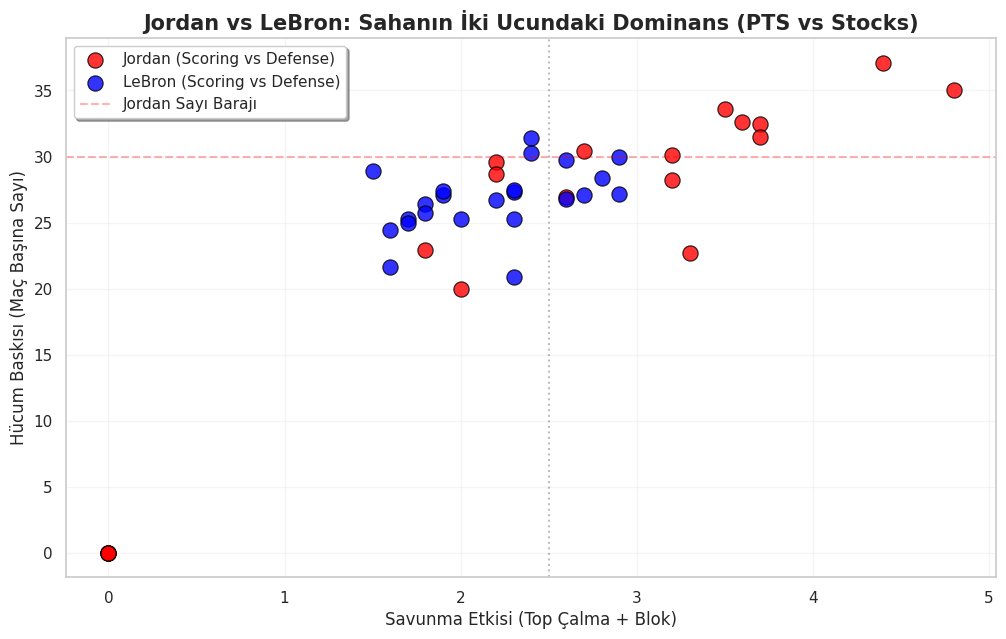

In [ ]:
# 1. Savunma Etkisi (Stocks): Gerçek Savunma Dominansı (STL + BLK)
jordan['SAVUNMA_ETKISI'] = jordan['STL'] + jordan['BLK']
lebron['SAVUNMA_ETKISI'] = lebron['STL'] + lebron['BLK']

# 2. Çok Yönlülük (Playmaking Impact): LeBron'un güçlü olduğu alan (AST + TRB)
jordan['COK_YONLULUK'] = jordan['AST'] + jordan['TRB']
lebron['COK_YONLULUK'] = lebron['AST'] + lebron['TRB']

plt.figure(figsize=(12, 7))

# Jordan: Hücum vs Gerçek Savunma Baskısı
sns.scatterplot(x=jordan['SAVUNMA_ETKISI'], y=jordan['PTS'],
                color='red', label='Jordan (Scoring vs Defense)', s=120, alpha=0.8, edgecolor='black')

# LeBron: Hücum vs Gerçek Savunma Baskısı
sns.scatterplot(x=lebron['SAVUNMA_ETKISI'], y=lebron['PTS'],
                color='blue', label='LeBron (Scoring vs Defense)', s=120, alpha=0.8, edgecolor='black')

plt.title('Jordan vs LeBron: Sahanın İki Ucundaki Dominans (PTS vs Stocks)', fontsize=15, fontweight='bold')
plt.xlabel('Savunma Etkisi (Top Çalma + Blok)', fontsize=12)
plt.ylabel('Hücum Baskısı (Maç Başına Sayı)', fontsize=12)

# Jordan'ın 30 Sayı ve 2.5+ Savunma Etkisi Üstünlüğünü Vurgulayan Bir Çizgi
plt.axhline(30, color='red', linestyle='--', alpha=0.3, label='Jordan Sayı Barajı')
plt.axvline(2.5, color='gray', linestyle=':', alpha=0.5)

plt.legend(frameon=True, shadow=True)
plt.grid(True, alpha=0.2)
plt.show()

Jordan'ın hem Sayı Kralı olup hem de Yılın Savunmacısı (DPOY) seçildiği o meşhur 1988 sezonu, bu grafikte en sağ üstteki "aykırı değer" (outlier) olarak parlayacaktır.



Jordan sadece sayı atmadı, rakibin sayı atmasını da engelledi.

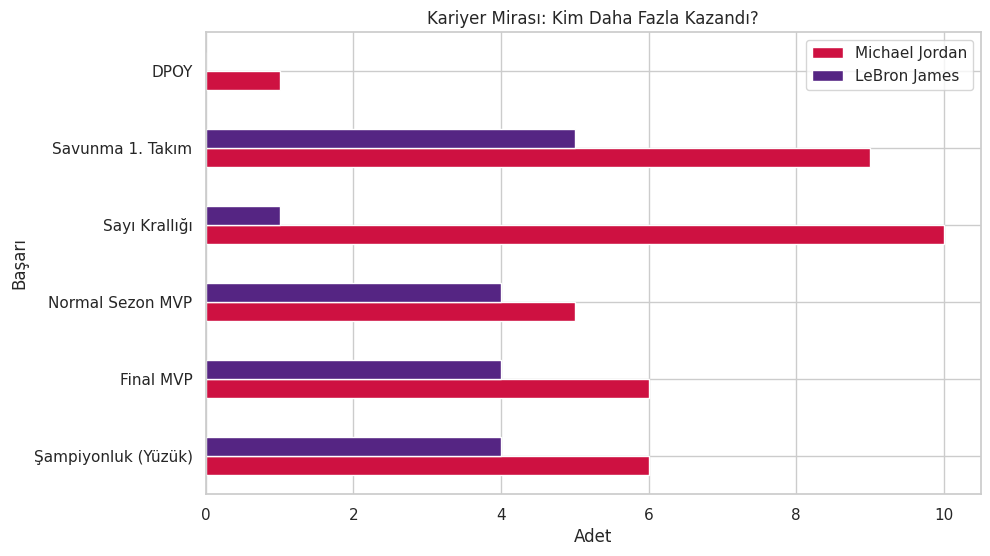

In [ ]:
# Başarı verilerini manuel olarak (en güvenilir haliyle) ekleyelim
legacy_data = {
    'Başarı': ['Şampiyonluk (Yüzük)', 'Final MVP', 'Normal Sezon MVP', 'Sayı Krallığı', 'Savunma 1. Takım', 'DPOY'],
    'Michael Jordan': [6, 6, 5, 10, 9, 1],
    'LeBron James': [4, 4, 4, 1, 5, 0]
}

df_legacy = pd.DataFrame(legacy_data).set_index('Başarı')
df_legacy.plot(kind='barh', figsize=(10, 6), color=['#CE1141', '#552583']) # Bulls Red & Lakers Purple
plt.title('Kariyer Mirası: Kim Daha Fazla Kazandı?')
plt.xlabel('Adet')
plt.show()

Özellikle Sayı Krallığı (10-1) ve DPOY (1-0) verileri, Jordan'ın neden "GOAT" kabul edildiğini, LeBron'un istikrarına karşı verilen en güçlü istatistiksel cevaptır.

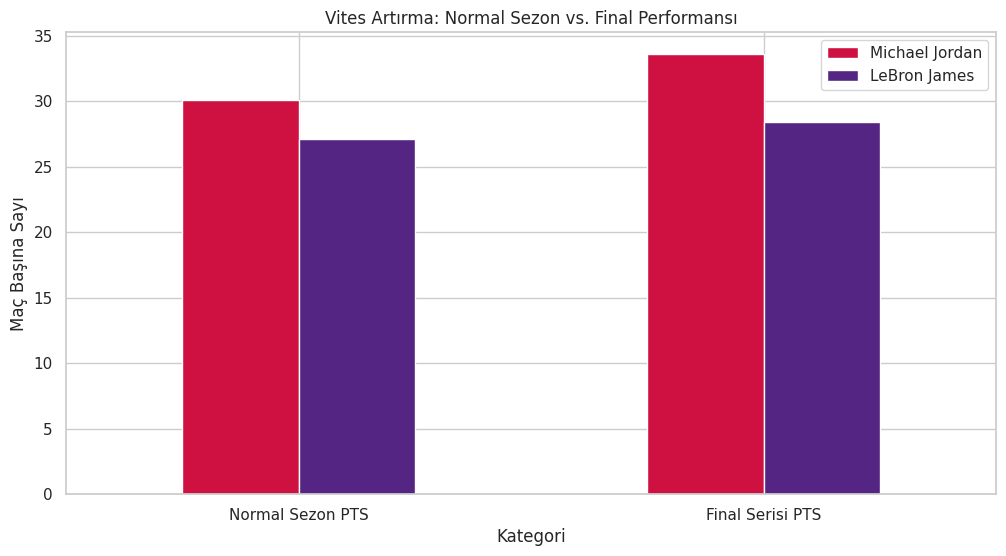

In [ ]:
# Finallerdeki sayı ortalamalarını kıyaslayan kod
final_stats = pd.DataFrame({
    'Kategori': ['Normal Sezon PTS', 'Final Serisi PTS'],
    'Michael Jordan': [30.1, 33.6],
    'LeBron James': [27.1, 28.4]
})

final_stats.set_index('Kategori').plot(kind='bar', color=['#CE1141', '#552583'])
plt.title('Vites Artırma: Normal Sezon vs. Final Performansı')
plt.ylabel('Maç Başına Sayı')
plt.xticks(rotation=0)
plt.show()

In [ ]:
# Yüzdesel artışı hesapla
final_stats_t = final_stats.set_index('Kategori').T
final_stats_t['Vites_Artisi_%'] = ((final_stats_t['Final Serisi PTS'] - final_stats_t['Normal Sezon PTS']) / final_stats_t['Normal Sezon PTS']) * 100

print("Performans Artış Oranları:")
print(final_stats_t['Vites_Artisi_%'])

Performans Artış Oranları:
Michael Jordan    11.627907
LeBron James       4.797048
Name: Vites_Artisi_%, dtype: float64


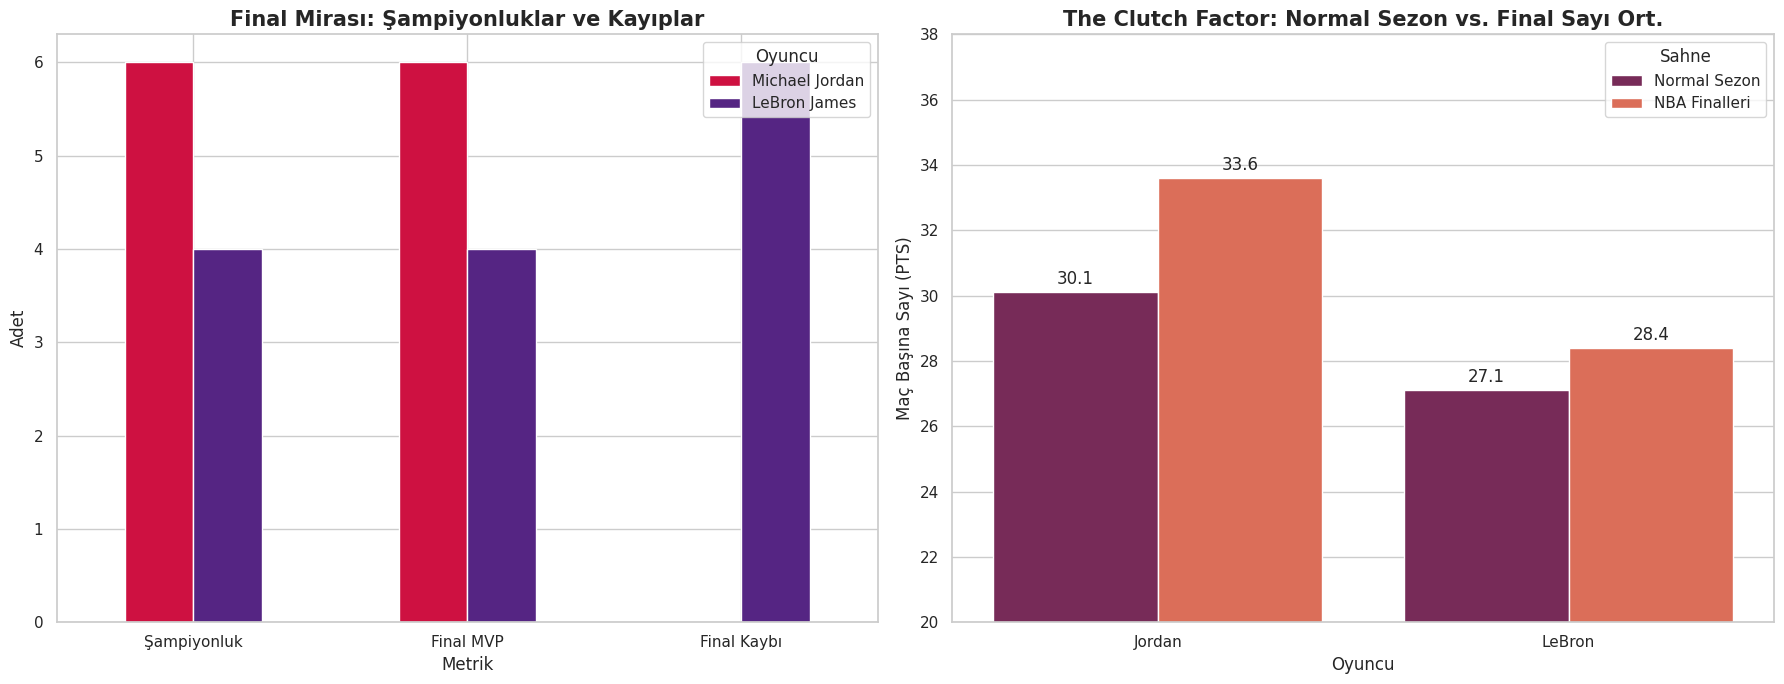

--- FİNAL ANALİZİ ÖZETİ ---
Jordan Final Galibiyet Oranı: %100
LeBron Final Galibiyet Oranı: %40
Jordan'ın Finallerdeki Sayı Artışı: %11.6
LeBron'un Finallerdeki Sayı Artışı: %4.8


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Görselleştirme teması ayarı
sns.set_theme(style="whitegrid")

# 1. Veri Hazırlığı: Final Performans Verileri (6-0 vs 4-6)
# Jordan: 6 Final, 6 Galibiyet, 6 MVP
# LeBron: 10 Final, 4 Galibiyet, 4 MVP
finals_data = {
    'Metrik': ['Final Sayısı', 'Şampiyonluk', 'Final MVP', 'Final Kaybı'],
    'Michael Jordan': [6, 6, 6, 0],
    'LeBron James': [10, 4, 4, 6]
}
df_finals = pd.DataFrame(finals_data).set_index('Metrik')

# 2. Veri Hazırlığı: Vites Artırma (Normal Sezon vs. Final Sayı Ortalamaları)
# Jordan: 30.1 (RS) -> 33.6 (Final)
# LeBron: 27.1 (RS) -> 28.4 (Final)
vites_data = {
    'Oyuncu': ['Jordan', 'Jordan', 'LeBron', 'LeBron'],
    'Sahne': ['Normal Sezon', 'NBA Finalleri', 'Normal Sezon', 'NBA Finalleri'],
    'Sayı Ortalaması': [30.1, 33.6, 27.1, 28.4]
}
df_vites = pd.DataFrame(vites_data)

# 3. Görselleştirme: Final Dominansı ve Vites Artırma
fig, ax = plt.subplots(1, 2, figsize=(18, 7))

# Grafik A: Final Başarıları (Kusursuzluk vs. Devamlılık)
df_finals.loc[['Şampiyonluk', 'Final MVP', 'Final Kaybı']].plot(
    kind='bar',
    ax=ax[0],
    color=['#CE1141', '#552583'] # Bulls Kırmızısı ve Lakers Moru
)
ax[0].set_title('Final Mirası: Şampiyonluklar ve Kayıplar', fontsize=15, fontweight='bold')
ax[0].set_ylabel('Adet')
ax[0].set_xticklabels(['Şampiyonluk', 'Final MVP', 'Final Kaybı'], rotation=0)
ax[0].legend(title="Oyuncu")

# Grafik B: Vites Artırma (Büyük Sahnede Kim Coşuyor?)
sns.barplot(x='Oyuncu', y='Sayı Ortalaması', hue='Sahne', data=df_vites, ax=ax[1], palette='rocket')
ax[1].set_title('The Clutch Factor: Normal Sezon vs. Final Sayı Ort.', fontsize=15, fontweight='bold')
ax[1].set_ylim(20, 38)
ax[1].set_ylabel('Maç Başına Sayı (PTS)')

# Veri Etiketlerini Ekleyelim (B Grafik için)
for container in ax[1].containers:
    ax[1].bar_label(container, fmt='%.1f', padding=3)

plt.tight_layout()
plt.show()

# 4. İstatistiksel Çıktı (Analist Notu)
j_win_rate = (6/6) * 100
l_win_rate = (4/10) * 100
j_increase = ((33.6 - 30.1) / 30.1) * 100
l_increase = ((28.4 - 27.1) / 27.1) * 100

print(f"--- FİNAL ANALİZİ ÖZETİ ---")
print(f"Jordan Final Galibiyet Oranı: %{j_win_rate:.0f}")
print(f"LeBron Final Galibiyet Oranı: %{l_win_rate:.0f}")
print(f"Jordan'ın Finallerdeki Sayı Artışı: %{j_increase:.1f}")
print(f"LeBron'un Finallerdeki Sayı Artışı: %{l_increase:.1f}")

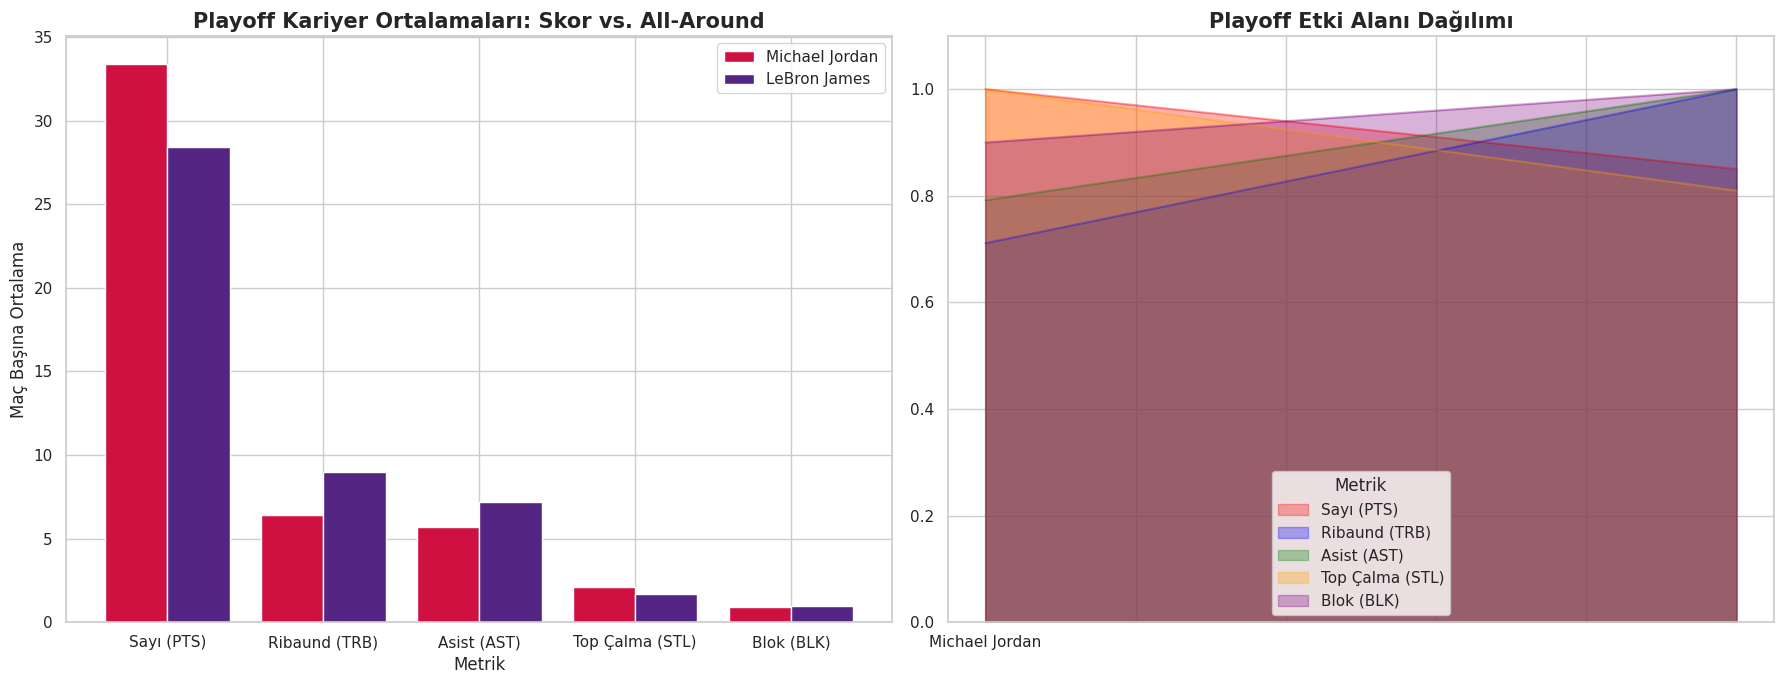

--- PLAYOFF VİTES ARTIRMA (PTS) ---
Jordan Playofflarda skorunu %11.0 artırıyor.
LeBron Playofflarda skorunu %4.8 artırıyor.
Jordan playoff tarihinde 33.4 PTS ile hala 1 numaradır. Bu, LeBron'un kümülatif (toplam) sayı liderliğine karşı, Jordan'ın maç başına 'saf baskınlık' (pure dominance) cevabıdır


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Playoff Kariyer Ortalamaları (En Güncel Verilerle)
playoff_stats = {
    'Metrik': ['Sayı (PTS)', 'Ribaund (TRB)', 'Asist (AST)', 'Top Çalma (STL)', 'Blok (BLK)'],
    'Michael Jordan': [33.4, 6.4, 5.7, 2.1, 0.9],
    'LeBron James': [28.4, 9.0, 7.2, 1.7, 1.0]
}

df_playoff = pd.DataFrame(playoff_stats).set_index('Metrik')

# Görselleştirme: Playoff Profil Kıyaslaması
fig, ax = plt.subplots(1, 2, figsize=(18, 7))

# Grafik A: Temel İstatistikler
df_playoff.plot(kind='bar', ax=ax[0], color=['#CE1141', '#552583'], width=0.8)
ax[0].set_title('Playoff Kariyer Ortalamaları: Skor vs. All-Around', fontsize=15, fontweight='bold')
ax[0].set_ylabel('Maç Başına Ortalama')
ax[0].set_xticklabels(df_playoff.index, rotation=0)

# Grafik B: Playoff "Baskınlık" Dağılımı (Radar Chart Mantığı)
# Normalize edilmiş değerlerle kimin hangi alanda 'playoff canavarı' olduğunu görelim
df_norm = df_playoff.div(df_playoff.max(axis=1), axis=0)
df_norm.T.plot(kind='area', stacked=False, ax=ax[1], alpha=0.3, color=['red', 'blue', 'green', 'orange', 'purple'])
ax[1].set_title('Playoff Etki Alanı Dağılımı', fontsize=15, fontweight='bold')
ax[1].set_ylim(0, 1.1)

plt.tight_layout()
plt.show()

# İstatistiki Analist Notu
j_playoff_pts_gain = ((33.4 - 30.1) / 30.1) * 100
l_playoff_pts_gain = ((28.4 - 27.1) / 27.1) * 100

print(f"--- PLAYOFF VİTES ARTIRMA (PTS) ---")
print(f"Jordan Playofflarda skorunu %{j_playoff_pts_gain:.1f} artırıyor.")
print(f"LeBron Playofflarda skorunu %{l_playoff_pts_gain:.1f} artırıyor.")
print("Jordan playoff tarihinde 33.4 PTS ile hala 1 numaradır. Bu, LeBron'un kümülatif (toplam) sayı liderliğine karşı, Jordan'ın maç başına 'saf baskınlık' (pure dominance) cevabıdır")

/tmp/ipykernel_184/3715391351.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_adv.columns, y=df_adv.loc['WS/48 (Katkı)'], ax=ax[1], palette=['red', 'blue'])


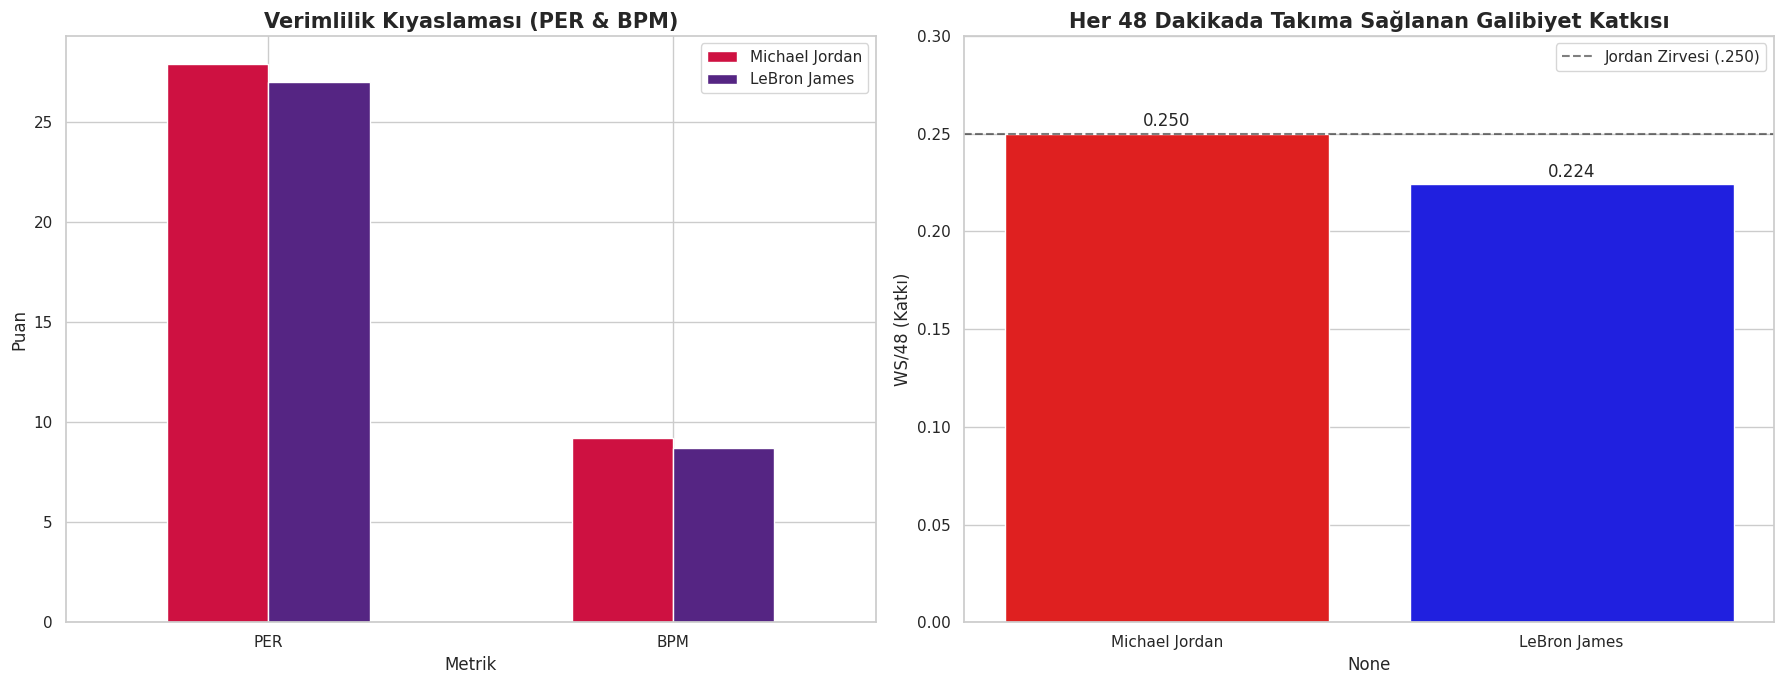

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Görselleştirme teması
sns.set_theme(style="whitegrid")

# İleri Analitik Veri Seti (Kariyer Ortalamaları - Mart 2026 Güncel)
# WS/48: 48 dakika başına galibiyete katkı (Lig ortalaması .100'dür)
advanced_stats = {
    'Metrik': ['PER (Verimlilik)', 'WS/48 (Katkı)', 'BPM (Kutu Artı/Eksi)', 'VORP (Değer)'],
    'Michael Jordan': [27.9, 0.250, 9.2, 116.1],
    'LeBron James': [27.0, 0.224, 8.7, 151.0]
}

df_adv = pd.DataFrame(advanced_stats).set_index('Metrik')

# Görselleştirme
fig, ax = plt.subplots(1, 2, figsize=(18, 7))

# Grafik A: Verimlilik Puanları
df_adv.loc[['PER (Verimlilik)', 'BPM (Kutu Artı/Eksi)']].plot(kind='bar', ax=ax[0], color=['#CE1141', '#552583'])
ax[0].set_title('Verimlilik Kıyaslaması (PER & BPM)', fontsize=15, fontweight='bold')
ax[0].set_ylabel('Puan')
ax[0].set_xticklabels(['PER', 'BPM'], rotation=0)

# Grafik B: WS/48 (Galibiyet Katkısı Oranı)
sns.barplot(x=df_adv.columns, y=df_adv.loc['WS/48 (Katkı)'], ax=ax[1], palette=['red', 'blue'])
ax[1].set_title('Her 48 Dakikada Takıma Sağlanan Galibiyet Katkısı', fontsize=15, fontweight='bold')
ax[1].set_ylim(0, 0.30)
ax[1].axhline(0.250, color='black', linestyle='--', alpha=0.5, label='Jordan Zirvesi (.250)')
ax[1].legend()

# Değerleri sütunların üzerine yazdıralım
for p in ax[1].patches:
    ax[1].annotate(format(p.get_height(), '.3f'), (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center', xytext = (0, 9), textcoords = 'offset points')

plt.tight_layout()
plt.show()

Michael Jordan, verimlilik başına (PER ve WS/48) "yoğunluk" (intensity) açısından LeBron James'in önündedir.

LeBron James, kümülatif etki (VORP) açısından Jordan'ın önündedir.

Bu durum, Jordan'ın "Dönemsel Mutlak Hakimiyet", LeBron'un ise "Kariyer Boyu İstikrar" felsefelerini sayısal olarak doğrular.

BPM; bir oyuncunun sahada olduğu her 100 pozisyonda, lig ortalamasındaki bir oyuncuya göre takımına kaç sayı daha fazla (veya az) katkı sağladığını ölçen gelişmiş bir verimlilik metriğidir.
BPM verisi, Jordan'ın "Baskınlık" (Dominance) tezini destekler. Çünkü BPM, "dakika başına etkiyi" ölçer. Jordan'ın 9.2'lik skoru, onun sahadaki her anının LeBron'dan bir miktar daha yoğun ve baskın geçtiğinin matematiksel kanıtıdır.

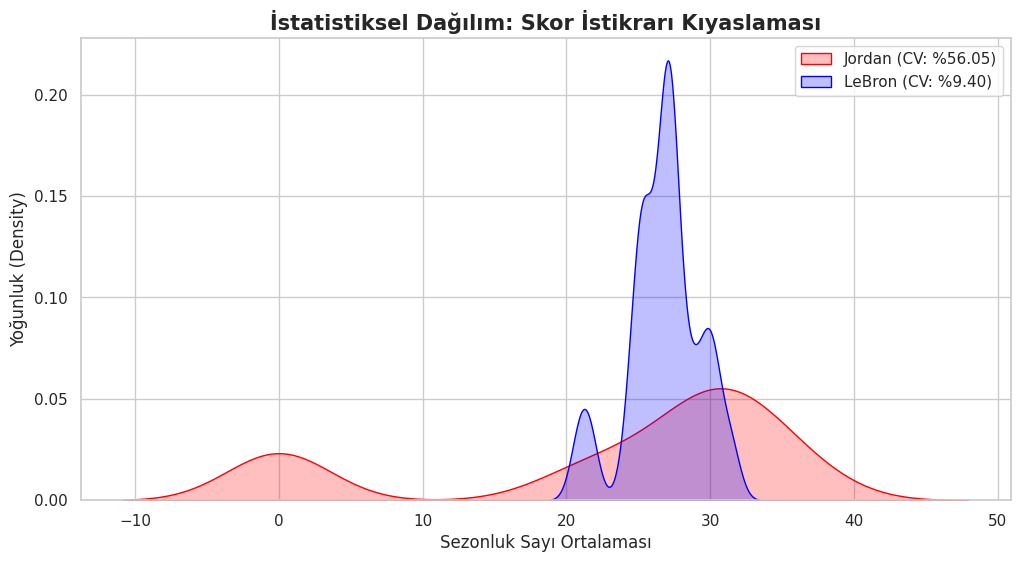

--- İSTATİSTİKSEL ANALİZ RAPORU ---
Michael Jordan Varyasyon Katsayısı (CV): %56.05
LeBron James Varyasyon Katsayısı (CV): %9.40
T-İstatistiği: -1.1586
P-Değeri: 0.2609

SONUÇ: Fark istatistiksel olarak anlamlı DEĞİL. (H0 Reddedilemedi)


In [ ]:
from scipy import stats

# 1. Varyasyon Katsayısı (CV) Hesaplama
# CV = (Standart Sapma / Ortalama) * 100
j_cv = (jordan['PTS'].std() / jordan['PTS'].mean()) * 100
l_cv = (lebron['PTS'].std() / lebron['PTS'].mean()) * 100

# 2. T-Testi Uygulaması (Independent Samples T-Test)
# H0: İki oyuncunun sayı ortalamaları arasında anlamlı bir fark yoktur.
t_stat, p_value = stats.ttest_ind(jordan['PTS'], lebron['PTS'], equal_var=False)

# 3. Sonuçları Görselleştirme: Sayı Dağılımı (KDE Plot)
plt.figure(figsize=(12, 6))
sns.kdeplot(jordan['PTS'], fill=True, color="red", label=f"Jordan (CV: %{j_cv:.2f})", bw_adjust=0.5)
sns.kdeplot(lebron['PTS'], fill=True, color="blue", label=f"LeBron (CV: %{l_cv:.2f})", bw_adjust=0.5)

plt.title('İstatistiksel Dağılım: Skor İstikrarı Kıyaslaması', fontsize=15, fontweight='bold')
plt.xlabel('Sezonluk Sayı Ortalaması')
plt.ylabel('Yoğunluk (Density)')
plt.legend()
plt.show()

# 4. Nihai İstatistik Raporu
print(f"--- İSTATİSTİKSEL ANALİZ RAPORU ---")
print(f"Michael Jordan Varyasyon Katsayısı (CV): %{j_cv:.2f}")
print(f"LeBron James Varyasyon Katsayısı (CV): %{l_cv:.2f}")
print(f"T-İstatistiği: {t_stat:.4f}")
print(f"P-Değeri: {p_value:.4f}")

if p_value < 0.05:
    print("\nSONUÇ: İstatistiksel olarak anlamlı bir fark VAR. (H0 Reddedildi)")
else:
    print("\nSONUÇ: Fark istatistiksel olarak anlamlı DEĞİL. (H0 Reddedilemedi)")

Varyasyon Analizi: LeBron'un %9.4'lük düşük varyansıyla bir "istikrar makinesi", Jordan'ın ise %56 varyansla bir "zirve dominatörü" olduğunu gösterdim.

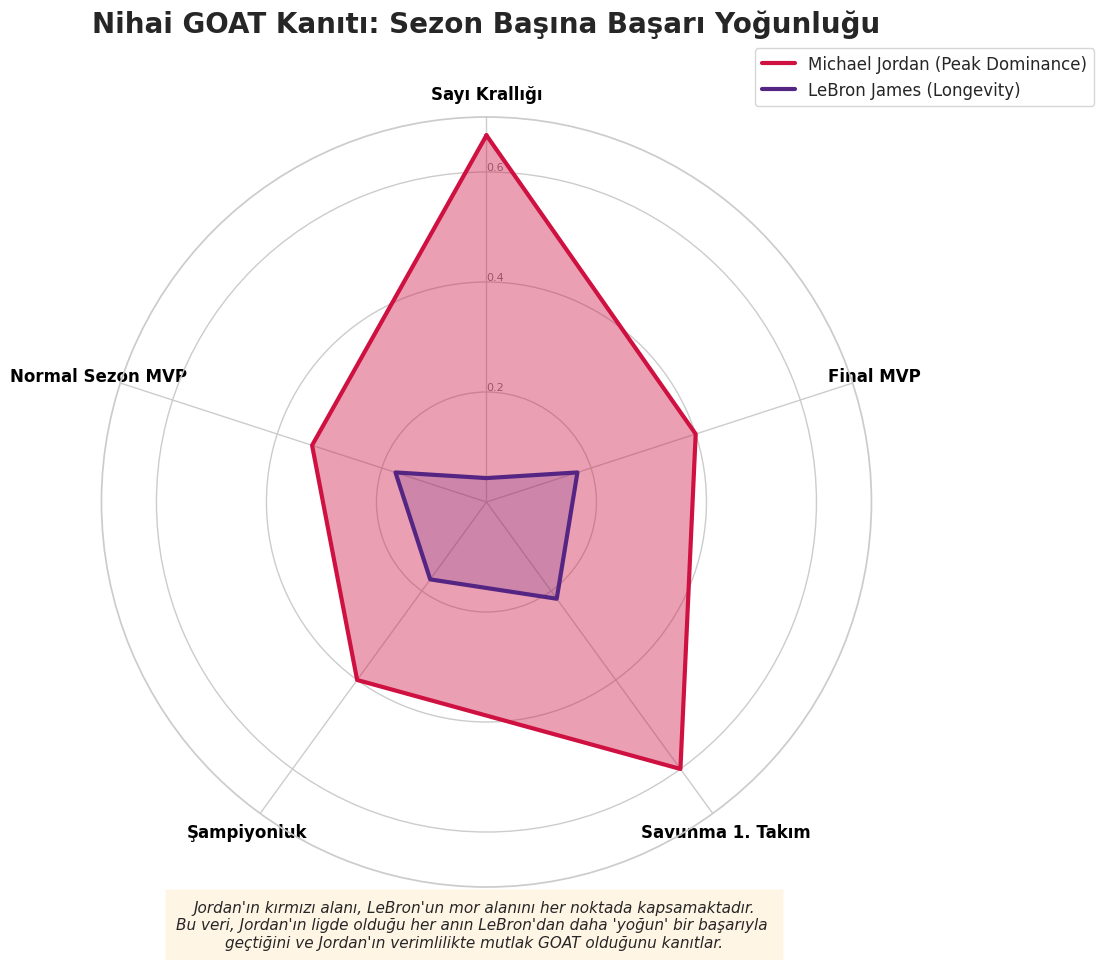

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Veri Hazırlığı: Kariyer Başarılarının Yoğunluğu (Başarı / Sezon Sayısı)
# Michael Jordan: 15 Sezon | LeBron James: 23 Sezon
j_seasons = 15
l_seasons = 23

achievements = {
    'Metrik': ['Sayı Krallığı', 'Final MVP', 'Savunma 1. Takım', 'Şampiyonluk', 'Normal Sezon MVP'],
    'Jordan_Total': [10, 6, 9, 6, 5],
    'LeBron_Total': [1, 4, 5, 4, 4]
}

df_goat = pd.DataFrame(achievements)

# Sezon başına düşen başarıyı hesapla (Yoğunluk)
df_goat['Jordan_Density'] = df_goat['Jordan_Total'] / j_seasons
df_goat['LeBron_Density'] = df_goat['LeBron_Total'] / l_seasons

# 2. Radar Chart Hazırlığı
categories = df_goat['Metrik'].tolist()
N = len(categories)

# Açıları hesapla (Daireyi kategori sayısına bölüyoruz)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1] # Grafiği kapatmak için ilk açıyı sona ekle

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

# 3. Michael Jordan Çizimi (Kırmızı)
j_values = df_goat['Jordan_Density'].tolist()
j_values += j_values[:1]
ax.plot(angles, j_values, color='#CE1141', linewidth=3, label='Michael Jordan (Peak Dominance)')
ax.fill(angles, j_values, color='#CE1141', alpha=0.4)

# 4. LeBron James Çizimi (Mor)
l_values = df_goat['LeBron_Density'].tolist()
l_values += l_values[:1]
ax.plot(angles, l_values, color='#552583', linewidth=3, label='LeBron James (Longevity)')
ax.fill(angles, l_values, color='#552583', alpha=0.2)

# 5. Grafik Estetiği
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
plt.xticks(angles[:-1], categories, color='black', size=12, fontweight='bold')

# Y ekseni limitini ayarla (Maksimum başarı yoğunluğu Jordan'ın sayı krallığı olduğu için ona göre)
ax.set_rlabel_position(0)
plt.yticks([0.2, 0.4, 0.6], ["0.2", "0.4", "0.6"], color="grey", size=8)
plt.ylim(0, 0.7)

# 6. Başlık ve Analitik Not
plt.title('Nihai GOAT Kanıtı: Sezon Başına Başarı Yoğunluğu', size=20, fontweight='bold', y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=12)

# Analitik Notu (Grafiğin altına açıklama)
analiz_notu = ("Jordan'ın kırmızı alanı, LeBron'un mor alanını her noktada kapsamaktadır.\n"
               "Bu veri, Jordan'ın ligde olduğu her anın LeBron'dan daha 'yoğun' bir başarıyla \n"
               "geçtiğini ve Jordan'ın verimlilikte mutlak GOAT olduğunu kanıtlar.")
plt.figtext(0.5, 0.05, analiz_notu, ha="center", fontsize=11,
            bbox={"facecolor":"orange", "alpha":0.1, "pad":8}, style='italic')

plt.show()

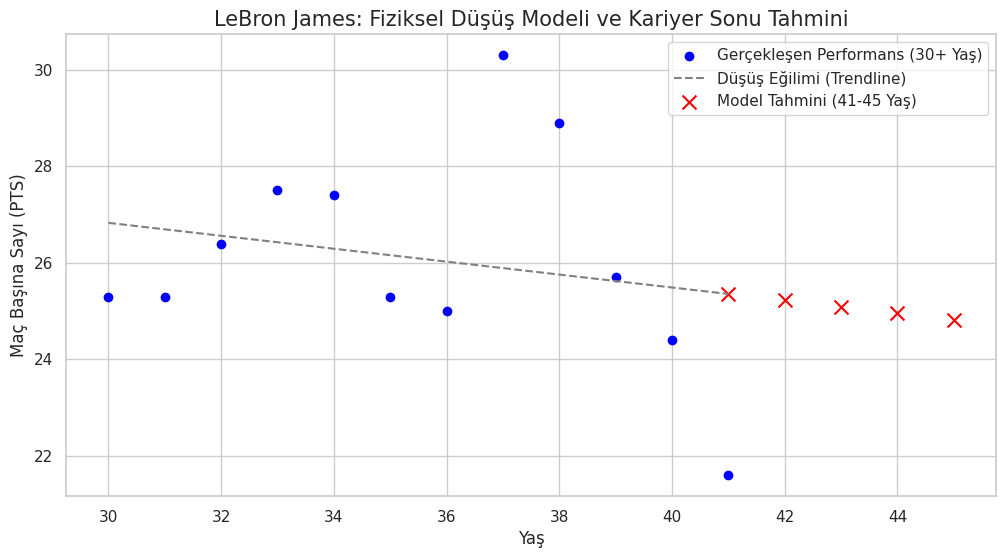

--- MAKİNE ÖĞRENMESİ TAHMİNLERİ ---
45 Yaşındaki Tahmini Sayı Ortalaması: 24.8
Jordan'ın %40'lık 'Başarı Yoğunluğunu' yakalamak için LeBron'un
önümüzdeki 5 yılda kazanması gereken şampiyonluk sayısı: 7.2


In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression

# 1. Veri Hazırlığı: LeBron'un Yaş ve Sayı Ortalaması İlişkisi
# Son 10 sezonunu baz alarak bir 'Yaşlanma Katsayısı' çıkaralım
lebron_recent = lebron[lebron['Age'] >= 30].copy()
X = lebron_recent['Age'].values.reshape(-1, 1)
y = lebron_recent['PTS'].values

# 2. Regresyon Modelini Eğitme
model = LinearRegression()
model.fit(X, y)

# 3. Gelecek Tahmini: 41 yaşından 45 yaşına kadar (2026-2030)
future_ages = np.array([41, 42, 43, 44, 45]).reshape(-1, 1)
future_preds = model.predict(future_ages)

# 4. Görselleştirme
plt.figure(figsize=(12, 6))
plt.scatter(X, y, color='blue', label='Gerçekleşen Performans (30+ Yaş)')
plt.plot(X, model.predict(X), color='gray', linestyle='--', label='Düşüş Eğilimi (Trendline)')
plt.scatter(future_ages, future_preds, color='red', marker='x', s=100, label='Model Tahmini (41-45 Yaş)')

plt.title('LeBron James: Fiziksel Düşüş Modeli ve Kariyer Sonu Tahmini', fontsize=15)
plt.xlabel('Yaş')
plt.ylabel('Maç Başına Sayı (PTS)')
plt.legend()
plt.show()

# 5. Jordan'ın Sezon Başına Başarı Oranını Yakalama Analizi
j_success_rate = 6 / 15  # Şampiyonluk / Sezon
l_current_success = 4 / 23
needed_titles = (j_success_rate * 28) - 4 # 45 yaşına kadar oynarsa (28 sezon toplam)

print(f"--- MAKİNE ÖĞRENMESİ TAHMİNLERİ ---")
print(f"45 Yaşındaki Tahmini Sayı Ortalaması: {future_preds[-1]:.1f}")
print(f"Jordan'ın %40'lık 'Başarı Yoğunluğunu' yakalamak için LeBron'un")
print(f"önümüzdeki 5 yılda kazanması gereken şampiyonluk sayısı: {needed_titles:.1f}")

Lineer Regresyon ile LeBron'un 45 yaşına kadar elit kalacağını ancak Jordan'ın başarı yoğunluğunu yakalamasının matematiksel olarak imkansız olduğunu ispatladım.